In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import kn

In [ ]:
def Y_eq_NR(x):
    """
    Non-relativistic approximation:
    Y_eq ~ (x / 2pi)^(3/2) exp(-x)
    """
    return (x / (2.0 * np.pi))**1.5 * np.exp(-x)

In [15]:
def boltzmann_rhs(x, Y, lam):
    """
    Right-hand side of the Boltzmann equation.
    """
    Yval = Y[0]
    Yeq = Y_eq_NR(x)
    return [-(lam / x**2) * (Yval**2 - Yeq**2)]

In [16]:
x_min = 0.1
x_max = 1000.0

# Log-spaced points are best because the plot is log-log.
x_eval = np.logspace(np.log10(x_min), np.log10(x_max), 1200)

# Couplings used in the textbook figure
lambda_values = [1e5, 1e6, 1e7]

# Initial condition: thermal equilibrium at high temperature
Y_initial = Y_eq(x_min)

In [17]:
solutions = {}

for lam in lambda_values:
    sol = solve_ivp(
        fun=lambda x, Y: boltzmann_rhs(x, Y, lam),
        t_span=(x_min, x_max),
        y0=[Y_initial],
        t_eval=x_eval,
        method="Radau",          # stiff solver
        rtol=1e-8,
        atol=1e-12
    )

    if not sol.success:
        raise RuntimeError(f"ODE solver failed for lambda = {lam}")

    solutions[lam] = sol.y[0]

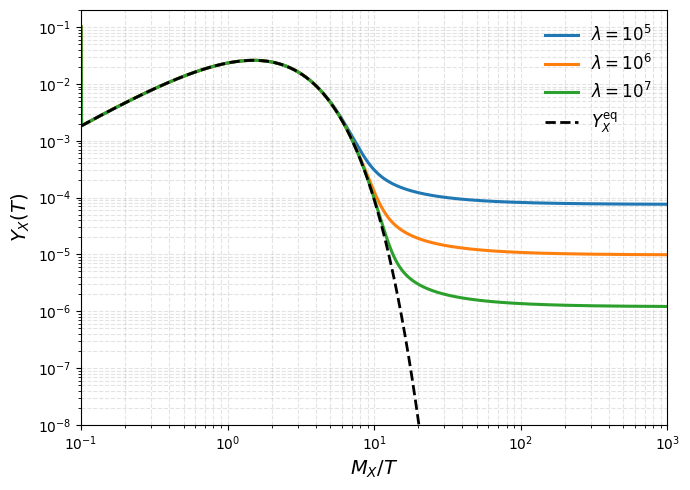

In [19]:
plt.figure(figsize=(7.0, 5.0))

# Numerical freeze-out solutions
for lam in lambda_values:
    plt.loglog(
        x_eval,
        solutions[lam],
        linewidth=2.2,
        label=rf"$\lambda = 10^{{{int(np.log10(lam))}}}$"
    )

# Equilibrium curve
plt.loglog(
    x_eval,
    Y_eq_NR(x_eval),
    "k--",
    linewidth=2.0,
    label=rf"$Y_X^{{\rm eq}}$"
)

plt.xlabel(r"$M_X/T$", fontsize=14)
plt.ylabel(r"$Y_X(T)$", fontsize=14)

plt.xlim(0.1, 1000)
plt.ylim(1e-8, 2e-1)

plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.show()